# 6a Visualization overview

## 1 Setup

### Load libraries

In [ ]:
library(readxl)
library(RColorBrewer)
library(tidyverse)
library(dplyr)
library(ggplot2)
library(ggforce)
library(patchwork)
library(vegan)
library(ggh4x)
library(scales)
library(openxlsx)
library(tibble)

options(warn = -1)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: lattice

This is vegan 2.6-8


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




### Setup workspace

In [ ]:
# Set working directory to project folder
wd <- "/path/to/02_metabolomics"
setwd(wd)

### Define color palettes

In [5]:
# Color palettes for strains
wt_colors     <- brewer.pal(9, "Greens")
disfp_colors  <- brewer.pal(9, "Purples")
rescue_colors <- brewer.pal(9, "Blues")

# Choose shades
color_nr       <- 6
color_nr_light <- 3

# Assigned strain colors
strain_colors       <- c(wt = wt_colors[color_nr], ko = disfp_colors[color_nr])
strain_colors_light <- c(wt = wt_colors[color_nr_light], ko = disfp_colors[color_nr_light])


# Color palettes for fold-change categories
abs_colors  <- brewer.pal(n = 9, name = "Blues")  # absent
down_colors <- brewer.pal(n = 9, name = "Blues")  # downregulated
up_colors   <- brewer.pal(n = 9, name = "Reds")   # upregulated

# Colors for change categories
change_colors <- c(
  "abs"  = abs_colors[6],
  "down" = down_colors[4],
  "up"   = up_colors[4],
  "none" = "darkgrey",
  "na"   = "lightgrey"
)

# Alpha transparency for plotting
change_alpha <- c(
  "down" = 1,
  "up"   = 1,
  "none" = 0.2
)

# ClassyFire superclass colors
ClassyFire.superclass.colors <- c(
  "Organic nitrogen compounds"         = "#8DD3C7",
  "Organic acids and derivatives"      = "#FFD92F",
  "Nucleosides, nucleotides, and analogues" = "#386CB0",
  "Lipids and lipid-like molecules"    = "#F781BF",
  "unknown"                            = "#CCCCCC",
  "Benzenoids"                         = "#FF7F00",
  "Organoheterocyclic compounds"       = "#A6761D",
  "Organic 1,3-dipolar compounds"      = "#B3DE69",
  "Phenylpropanoids and polyketides"   = "#80B1D3",
  "Organic oxygen compounds"           = "#FDB462",
  "Alkaloids and derivatives"          = "#BC80BD",
  "Organosulfur compounds"             = "#CCEBC5",
  "Organometallic compounds"           = "#FFED6F",
  "Organophosphorus compounds"         = "#D9D9D9",
  "Organohalogen compounds"            = "#FB8072",
  "others"                             = "grey95"
)

# NPClassifier pathway colors
NPC.pathway.colors <- c(
  "Alkaloids"                      = "#8DD3C7",
  "Amino acids and Peptides"       = "#FFD92F",
  "Carbohydrates"                  = "#386CB0",
  "Fatty acids"                    = "#F781BF",
  "unknown"                        = "#CCCCCC",
  "Polyketides"                    = "#FF7F00",
  "Shikimates and Phenylpropanoids"= "#A6761D",
  "Terpenoids"                     = "#7FC97F",
  "others"                         = "grey95"
)


## 2 Load data

### Load Metadata

In [7]:
# Load sample metadata
md_path <- "02_data/tables/samplelist.xlsx"
md.load <- read_excel(md_path)
md <- md.load %>% filter(type %in% c("sample", "control"))

# Load group definitions
mdgroups_path <- "02_data/tables/grouplist.xlsx"
mdgroups <- read_excel(mdgroups_path)

### Load feature table

In [8]:
ft_filePath <- file.path(wd, "03_analysis", "tables", "featureTable.csv")
ft <- read.csv(ft_filePath)

## 3 Visualization

### Define parameters

In [9]:
pvalueTH         <- 0.01      # Significance threshold for statistical tests
log2fcTH         <- 2         # Absolute log2 fold change threshold for relevant features
samplePercentTH  <- 0.8       # Required presence in % of samples per group (e.g. 80%)
absentPercentTH  <- 0.15      # Max allowed presence in 'absent' group (e.g. 15%)
retentiontimeTH  <- 0.1       # Minimum retention time in minutes (to filter noise)
intTH            <- 100000    # Minimum intensity threshold for relevant features

### PCoA 

Perform Principal Coordinates Analysis (PCoA)  across the stages

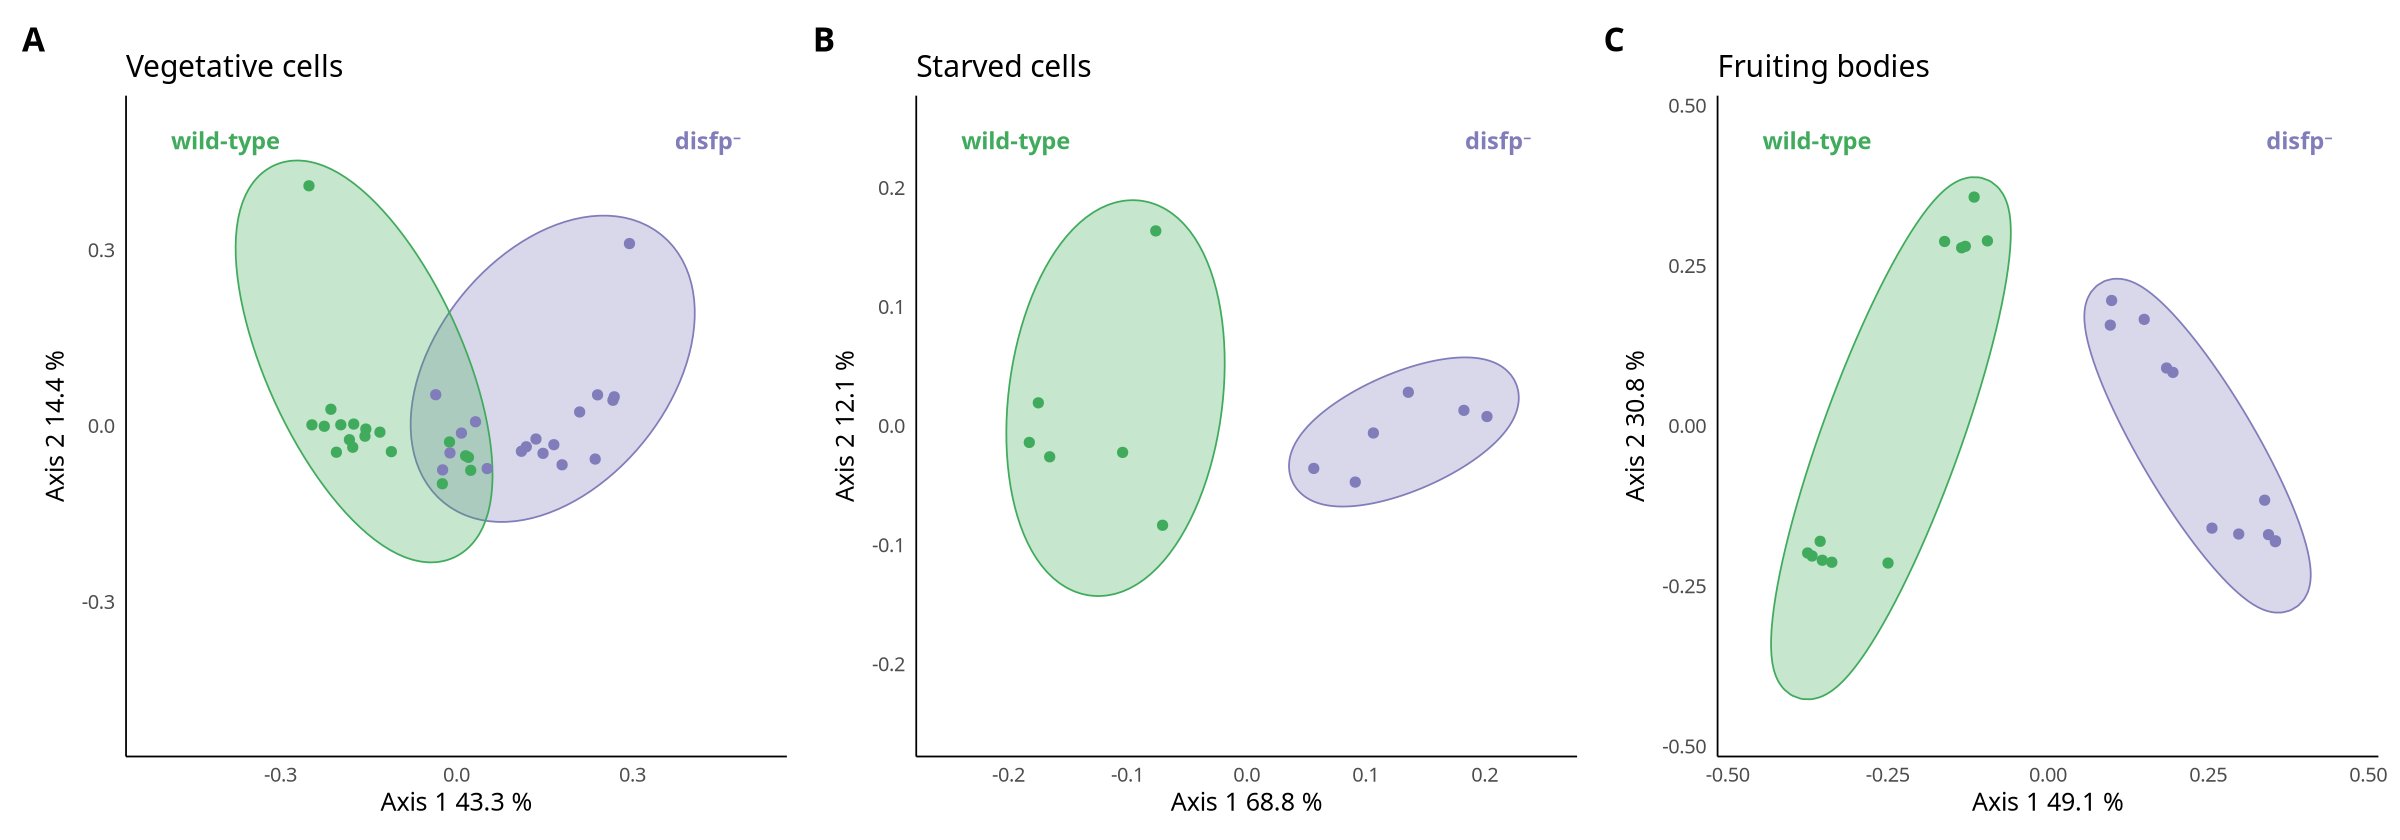

In [10]:
# Define genotype and column names
genotype <- rep(c("wt", "ko"), each = 3)
data_matrix_colnames <- c("  wt 1  ", "  wt 2  ", "  wt 3  ", "  ko 1  ", "  ko 2  ", "  ko 3  ")


# Define group labels and annotation data frame
group_labels <- genotype
annotation_col <- data.frame(Group = group_labels, row.names = data_matrix_colnames)

# Define annotation colors
annotation_colors <- list(Group = strain_colors)

# Define stages and change column names
stages <- list(
  veg = "change_veg",
  stv = "change_stv",
  fbs = "change_fbs"
)

# Prepare empty list to store plots
plots <- list()

# Loop through stages
for (i in 1:length(stages)) {
  stage <- names(stages)[i]
  change_col <- stages[[i]]
  
  # Select group info
  group <- mdgroups %>% filter(gene == "disfp") %>% slice(i)
  ref <- group$refName
  test <- group$testName
  
  # Get sample and genotype info
  samples_ref <- md %>% filter(strain_group == ref) %>% pull(name)
  samples_test <- md %>% filter(strain_group == test) %>% pull(name)
  genotype_ref <- md %>% filter(strain_group == ref) %>% pull(genotype)
  genotype_test <- md %>% filter(strain_group == test) %>% pull(genotype)
  genotype <- c(genotype_ref, genotype_test)
  
  # Prepare data
  ft_selected <- ft %>%
    filter(.data[[change_col]] != "na") %>%
    select(c(samples_ref, samples_test))
  ftt <- t(ft_selected)
  ftt_imputed <- apply(ftt, 2, function(x) ifelse(is.na(x), min(x, na.rm = TRUE), x))
  
  # Calculate distance and run PCoA
  dist_matrix <- vegdist(ftt_imputed, method = "bray")
  pcoa <- cmdscale(dist_matrix, eig = TRUE, k = 2)
  pcoa_points <- as.data.frame(pcoa$points)
  variance <- round((pcoa$eig / sum(pcoa$eig)) * 100, 1)
  names(pcoa_points)[1:2] <- c("Axis1", "Axis2")
  pcoa_points$genotype <- genotype
  pcoa_points$sample_name <- gsub("\\D", "", rownames(pcoa_points))
  
  max_limit <- max(abs(c(pcoa_points$Axis1, pcoa_points$Axis2))) * 1.25
  
  # Create plot
  plot <- ggplot(pcoa_points, aes(Axis1, Axis2, colour = genotype)) +
    ggforce::geom_mark_ellipse(aes(fill = genotype, filter = genotype == "ko"), con.type = "none") +
    ggforce::geom_mark_ellipse(aes(fill = genotype, filter = genotype == "wt"), con.type = "none") +
    annotate("text", x = -max_limit * 0.95, y = max_limit * 0.95, label = "wild-type", color = strain_colors[["wt"]], size = 5, fontface = "bold", hjust = 0) +
    annotate("text", x =  max_limit * 0.95, y = max_limit * 0.95, label = "disfp⁻", color = strain_colors[["ko"]], size = 5, fontface = "bold", hjust = 1) +
    geom_point(size = 2.5) +
    scale_fill_manual(values = strain_colors) +
    scale_color_manual(values = strain_colors) +
    xlab(paste("Axis 1", variance[1], "%")) +
    ylab(paste("Axis 2", variance[2], "%")) +
    ggtitle(switch(stage,
                   veg = "Vegetative cells",
                   stv = "Starved cells",
                   fbs = "Fruiting bodies")) +
    theme_minimal(base_size = 15) +
    theme(panel.grid = element_blank(),
          legend.position = "none", axis.line = element_line(size = 0.5, color = "black")) +
    coord_fixed(ratio = 1, xlim = c(-max_limit, max_limit), ylim = c(-max_limit, max_limit))
  
  plots[[stage]] <- plot
}

# Combine and display plots
options(repr.plot.width=20, repr.plot.height=7) 
combined_plot <- plots$veg | plots$stv | plots$fbs
combined_plot  + plot_annotation(tag_levels = 'A') & theme(plot.tag = element_text(size = 20, face = "bold"))


### Differential abundance




#### Levelshift
Generates volcano plots and cloud plots to visualize differential abundance across stages.  
Uses fold-change, p-values, and presence/absence annotations for filtering and plotting.

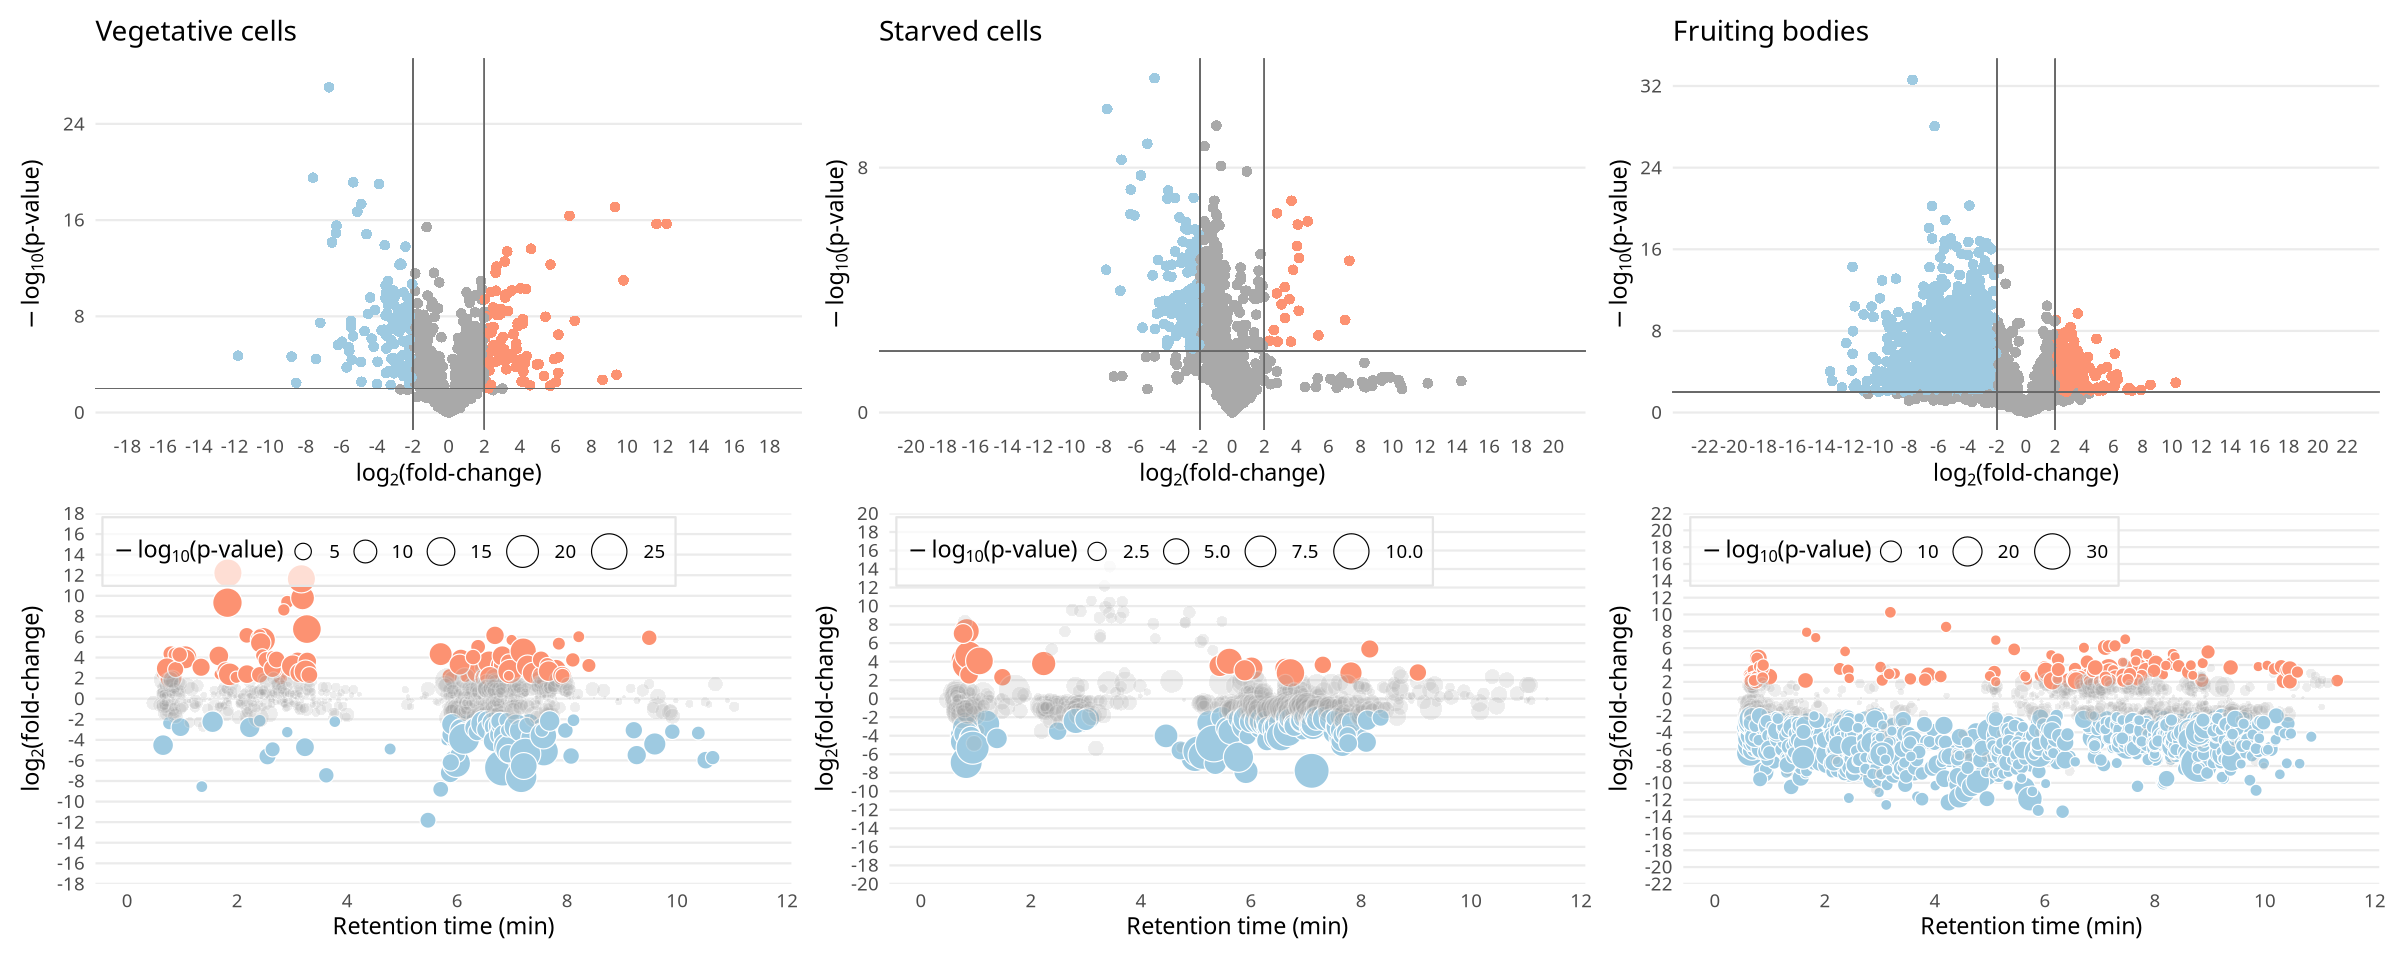

In [11]:
plot_vulcano <- function(ft, metaChange_selected, group_selected) {
  options(repr.plot.width = 25, repr.plot.height = 10)
  
  ft_selected <- ft %>%
    filter(!!sym(metaChange_selected) != "na", !!sym(metaChange_selected) != "abs")
  
  max_value <- max(abs(ft_selected[[paste0(group_selected, "log2FCimp")]]), na.rm = TRUE)
  rounded_limit <- ceiling(max_value / 2) * 2
  max_y <- ceiling(max(-log10(ft_selected[[paste0(group_selected, "pvalue")]]), na.rm = TRUE))
  
  ggplot(ft_selected, aes(
    x = !!sym(paste0(group_selected, "log2FCimp")), 
    y = -log10(!!sym(paste0(group_selected, "pvalue"))), 
    fill = !!sym(metaChange_selected))) + 
    geom_point(shape = 21, stroke = NA, size = 3) +
    geom_segment(aes(x = -log2fcTH, xend = -log2fcTH, y = -Inf, yend = Inf), colour = "dimgrey", size = 0.25) +
    geom_segment(aes(x = log2fcTH, xend = log2fcTH, y = -Inf, yend = Inf), colour = "dimgrey", size = 0.25) +
    geom_segment(aes(x = -Inf, xend = Inf, y = -log10(pvalueTH), yend = -log10(pvalueTH)), colour = "dimgrey", size = 0.25) +
    scale_x_continuous(limits = c(-rounded_limit, rounded_limit), breaks = seq(-rounded_limit, rounded_limit, 2)) +
    scale_y_continuous(breaks = seq(0, max_y, 8)) +
    coord_cartesian(xlim = c(-rounded_limit, rounded_limit), ylim = c(0, max_y)) +
    scale_fill_manual(values = change_colors) +
    labs(
      x = expression(log[2] * "(fold-change)"),
      y = expression(-log[10] * "(p-value)"),
      fill = "Differential abundance"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.minor.y = element_blank(),
      legend.position = c(0.99, 0.99),
      legend.justification = c("right", "top"),
      legend.background = element_rect(fill = alpha('white', 0.7), color = "grey90")
    ) +
    guides(fill = FALSE)
}

plot_cloud <- function(ft, metaChange_selected, group_selected) {
  options(repr.plot.width = 25, repr.plot.height = 10)
  
  ft_selected <- ft %>%
    filter(!!sym(metaChange_selected) != "na", !!sym(metaChange_selected) != "abs")
  
  max_y <- max(abs(ft_selected[[paste0(group_selected, "log2FCimp")]]), na.rm = TRUE)
  rounded_y <- ceiling(max_y / 2) * 2
  
  ggplot(ft_selected, aes(
    x = rt, 
    y = !!sym(paste0(group_selected, "log2FCimp")),
    size = -log10(!!sym(paste0(group_selected, "pvalue"))), 
    fill = !!sym(metaChange_selected),
    alpha = !!sym(metaChange_selected))) + 
    geom_point(shape = 21, color = "white") +
    scale_fill_manual(values = change_colors) +
    scale_alpha_manual(values = change_alpha) +
    scale_size_continuous(range = c(0.01, 10)) +
    coord_cartesian(xlim = c(0, 11.5), ylim = c(-rounded_y, rounded_y)) +
    scale_x_continuous(breaks = seq(0, 12, 2)) +
    scale_y_continuous(breaks = seq(-rounded_y, rounded_y, 2), expand = c(0, 0)) +
    labs(
      x = "Retention time (min)",
      y = expression(log[2] * "(fold-change)"),
      size = expression(-log[10] * "(p-value)")
    ) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.minor.y = element_blank(),
      legend.position = c(0.01, 0.99),
      legend.justification = c("left", "top"),
      legend.background = element_rect(fill = alpha('white', 0.7), color = "grey90")
    ) +
    guides(
      color = FALSE,
      fill = FALSE,
      alpha = FALSE,
      size = guide_legend(override.aes = list(color = "black"), direction = 'horizontal')
    )
}


# Generate plots for each stage
vg_vulcano <- plot_vulcano(ft, "change_veg", "veg_") + labs(title = "Vegetative cells")
sv_vulcano <- plot_vulcano(ft, "change_stv", "stv_") + labs(title = "Starved cells")
fb_vulcano <- plot_vulcano(ft, "change_fbs", "fbs_") + labs(title = "Fruiting bodies")

vg_cloud <- plot_cloud(ft, "change_veg", "veg_")
sv_cloud <- plot_cloud(ft, "change_stv", "stv_")
fb_cloud <- plot_cloud(ft, "change_fbs", "fbs_")

# Combine plots in a 2-row grid (volcano + cloud)
combined_plot <- (vg_vulcano + sv_vulcano + fb_vulcano) /
                 (vg_cloud + sv_cloud + fb_cloud)

options(repr.plot.width=20, repr.plot.height=8) 
combined_plot


#### Absence

Generates intensity plots for features absent in specific groups across stages.  
Plots peak intensity over retention time for absent features in vegetative, starved, and fruiting body stages.


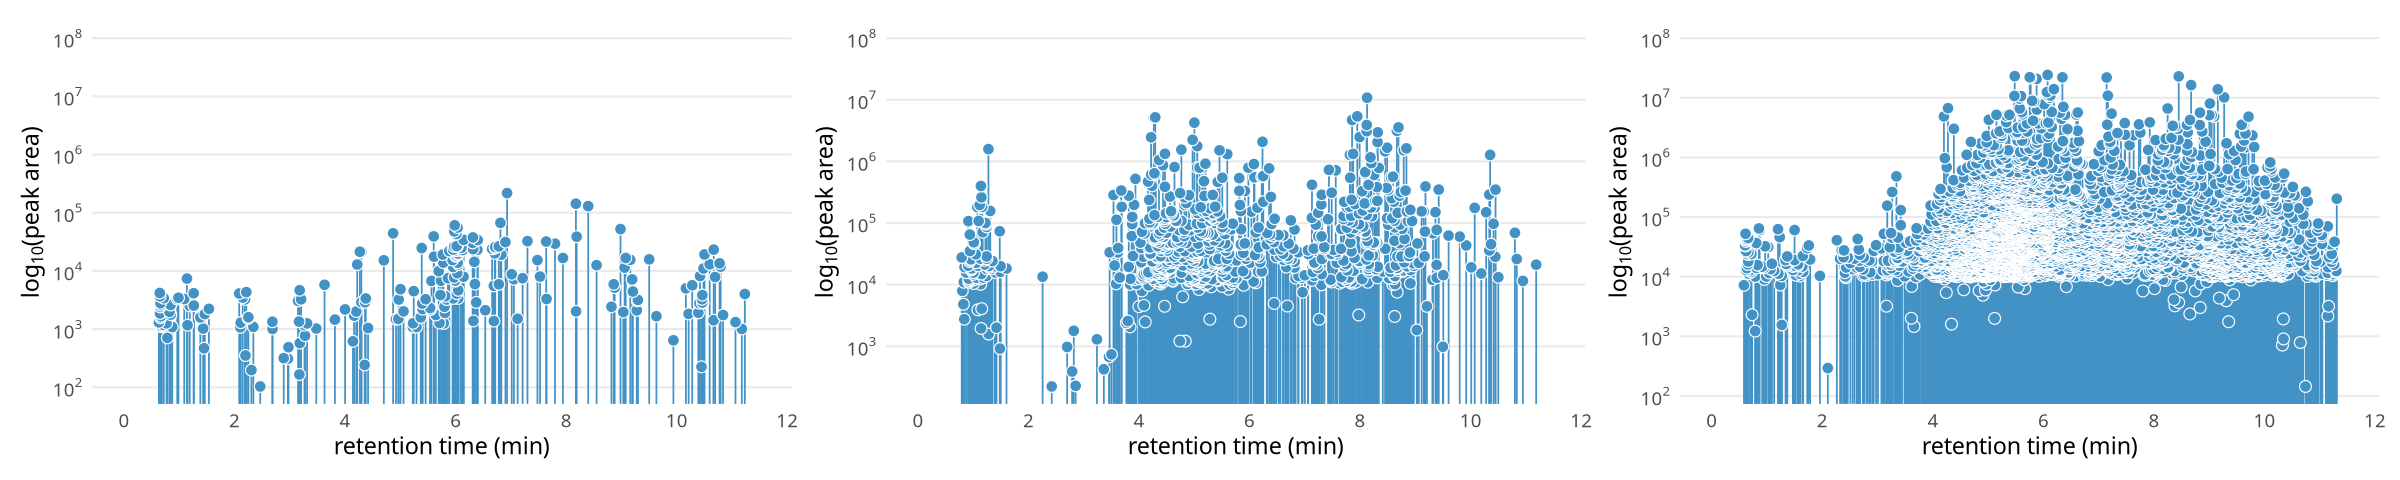

In [12]:
# Define plot_int function
plot_int <- function(ft, metaChange_selected, group_selected) {
  options(repr.plot.width = 25, repr.plot.height = 10)

  ft_selected <- ft %>%
    filter(!!sym(metaChange_selected) != "na") %>%
    filter(!!sym(metaChange_selected) == "abs") %>%
    mutate(stage_max_mean = pmax(!!sym(paste0(group_selected, "wt_mean")), !!sym(paste0(group_selected, "ko_mean"))))

  int_plot <- ft_selected %>%
    arrange(stage_max_mean) %>%
    ggplot(aes(
      x = rt,
      y = stage_max_mean,
      fill = !!sym(metaChange_selected),
      alpha = !!sym(metaChange_selected)
    )) +
    geom_segment(data = . %>% filter(!!sym(metaChange_selected) != "abs"), aes(x = rt, y = 0, yend = stage_max_mean, color = !!sym(metaChange_selected))) +
    geom_point(data = . %>% filter(!!sym(metaChange_selected) != "abs"), shape = 21, color = "white", size = 3) +
    geom_segment(data = . %>% filter(!!sym(metaChange_selected) == "abs"), aes(x = rt, y = 0, yend = stage_max_mean, color = !!sym(metaChange_selected))) +
    geom_point(data = . %>% filter(!!sym(metaChange_selected) == "abs"), shape = 21, color = "white", size = 3) +
    xlab("retention time (min)") +
    ylab(expression(log[10] * "(peak area)")) +
    scale_fill_manual(values = change_colors) +
    scale_color_manual(values = change_colors) +
    scale_alpha_manual(values = change_alpha) +
    scale_y_log10(breaks = trans_breaks("log10", function(x) 10^x),
                  labels = trans_format("log10", math_format(10^.x))) +
    coord_cartesian(xlim = c(0, 11.5), ylim = c(NA, 1e8)) +
    scale_x_continuous(breaks = seq(0, 12, by = 2)) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.minor.y = element_blank()
    ) +
    guides(color = FALSE, fill = FALSE, alpha = FALSE, size = FALSE)

  return(int_plot)
}

# Generate absence plots for each stage
vg_int <- plot_int(ft = ft, metaChange_selected = "change_veg", group_selected = "veg_")
sv_int <- plot_int(ft = ft, metaChange_selected = "change_stv", group_selected = "stv_")
fb_int <- plot_int(ft = ft, metaChange_selected = "change_fbs", group_selected = "fbs_")

# Combine plots in a single figure
options(repr.plot.width=20, repr.plot.height=4) 
(vg_int + sv_int + fb_int)


### Distributions
A collection of summary plots showing the distribution of differential abundance and compound annotations across developmental stages.

#### Preparing stage-specific feature tables
Filters and prepares stage-specific feature tables for vegetative cells, starved cells, and fruiting bodies.  
Columns are standardized and combined into a single table for downstream analysis.

In [13]:
# Function to prepare feature table for a given stage
prepare_stage_table <- function(stage_name) {
  change_col <- paste0("change_", stage_name)
  wt_mean_col <- paste0(stage_name, "_wt_mean")
  pvalue_col <- paste0(stage_name, "_pvalue")
  log2fc_col <- paste0(stage_name, "_log2FC")
  
  ft %>%
    filter(.data[[change_col]] != "na") %>%
    select(
      feature, mode, mz, rt, rt_range.min, rt_range.max,
      !!sym(change_col), !!sym(wt_mean_col), !!sym(pvalue_col), !!sym(log2fc_col),
      sirius_NPC.pathway, sirius_NPC.superclass, sirius_NPC.class,
      sirius_ClassyFire.superclass, sirius_ClassyFire.class, sirius_ClassyFire.subclass, msms
    ) %>%
    mutate(stage = stage_name) %>%
    rename(
      change = !!sym(change_col),
      wt_mean = !!sym(wt_mean_col),
      pvalue = !!sym(pvalue_col),
      log2FC = !!sym(log2fc_col)
    )
}

# Prepare all stages
ft_veg <- prepare_stage_table("veg")
ft_stv <- prepare_stage_table("stv")
ft_fb  <- prepare_stage_table("fbs")

# Combine into one table
ft_changes <- bind_rows(ft_veg, ft_stv, ft_fb)


Summarizes feature counts by stage and change type in table.

In [14]:
# Summarize the feature counts by stage and change category
ft_summary <- ft_changes %>%
  group_by(stage, change) %>%
  summarize(count = n(), .groups = 'drop') %>%
  pivot_wider(names_from = change, values_from = count, values_fill = 0) %>%
  mutate(
    total = rowSums(across(c(up, down, abs, none))),  # Sum across change categories
    stage = factor(stage, levels = c("veg", "stv", "fbs"))  # Ensure stage order
  ) %>%
  arrange(stage) %>%
  select(stage, up, down, abs, none, total)  # Final column order

# Print the summary table
ft_summary

stage,up,down,abs,none,total
<fct>,<int>,<int>,<int>,<int>,<dbl>
veg,93,106,215,2321,2735
stv,20,147,758,2174,3099
fbs,161,1539,4650,1567,7917


#### Change count overview



In [15]:
changeCount_overview_plot <- ft_changes %>%
  mutate(stage = factor(stage, levels = c("veg", "stv", "fbs")),
         change = factor(change, levels = c("abs", "down", "up", "none"))) %>%
  group_by(stage, change) %>%
  summarise(count = n(), .groups = 'drop') %>%
  ggplot(aes(fill = change, y = count, x = stage)) + 
    geom_bar(position = "stack", stat = "identity") +
    scale_x_discrete(labels = c("veg" = "vegetative\ncells",
                                "stv" = "starved\ncells",
                                "fbs" = "fruiting\nbodies")) +
    xlab(NULL) + 
    ylab("feature count") +
    labs(fill = NULL) +
    scale_fill_manual(values = change_colors,
                      labels = c("up" = "up", "down" = "down", "abs" = "absent", "none" = "none")) +
    theme_minimal(base_size = 14) +
    theme(
      legend.position = c(0.05, 0.95),
      legend.justification = c("left", "top"),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.minor.y = element_blank(),
      panel.grid.major.y = element_blank()
    )

#### Feature count distribution across intensity bins and MS2 coverage

In [16]:
# Calculate log10 bin edges for peak area
wt_max <- max(ft_changes$wt_mean, na.rm = TRUE)
wt_min <- min(ft_changes$wt_mean, na.rm = TRUE)
wt_log_max <- ceiling(log10(wt_max))
wt_log_min <- floor(log10(wt_min))
bin_edges <- unique(c(0, 1 * 10^(3:wt_log_max)))

# Dictionary for facet label renaming
rename_dict_bins_stages <- c(
  "veg"   = "vegetative cells", 
  "stv"   = "starved cells", 
  "fbs"   = "fruiting bodies",
  "TRUE"  = "MS2 data available",
  "FALSE" = "without MS2 data"
)
labeller_bins_stages <- as_labeller(rename_dict_bins_stages)

# Assign features to bins
ft_changes_bins <- ft_changes %>%
  mutate(
    stage  = factor(stage, levels = c("veg", "stv", "fbs")),
    change = factor(change, levels = c("abs", "down", "up", "none")),
    wt_log = log10(wt_mean),
    wt_bin = cut(wt_mean, breaks = bin_edges, include.lowest = TRUE)
  )

# Summarize feature counts per bin
ft_summary <- ft_changes_bins %>%
  group_by(stage, change, msms, wt_bin) %>%
  summarise(count = n(), .groups = "drop")

# Create bin labels for x-axis
bin_labels <- levels(ft_changes_bins$wt_bin)
valid_bins <- bin_labels[bin_labels %in% ft_summary$wt_bin]
bin_powers <- 3:9
bin_tick_labels <- setNames(
  lapply(bin_powers, function(x) bquote(1 * "\u00D7" * 10^.(x))),
  valid_bins
)

# Plot feature counts by bin, stage, change status, and MS2 availability
changeCount_overview_msms_bins <- ggplot(ft_summary, aes(fill = change, y = count, x = wt_bin)) +
  geom_bar(position = "stack", stat = "identity") +
  scale_x_discrete(labels = bin_tick_labels) +
  xlab("bins (peak area)") +
  ylab("feature count") +
  labs(fill = "Change") +
  scale_fill_manual(values = change_colors) +
  facet_grid(msms ~ stage, labeller = labeller_bins_stages) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank(),
    panel.grid.major.y = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )


#### ClassyFire superclass overview


In [17]:
CFsuperclassCount_overview_plot <- ft_changes %>%
  mutate(
    stage = factor(stage, levels = c("veg", "stv", "fbs")),
    change = factor(change, levels = c("abs", "down", "up", "none"))
  ) %>%
  group_by(stage, sirius_ClassyFire.superclass) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(stage) %>%
  mutate(count_normalized = count / sum(count) * 100) %>%  # normalize within stage
  ggplot(aes(fill = sirius_ClassyFire.superclass, y = count_normalized, x = stage)) +
    geom_bar(position = "stack", stat = "identity") +
    scale_x_discrete(labels = c("veg" = "vegetative\ncells",
                                "stv" = "starved\ncells",
                                "fbs" = "fruiting\nbodies")) +
    xlab(NULL) +
    ylab("feature count") +
    labs(fill = NULL) +
    scale_fill_manual(values = ClassyFire.superclass.colors) +
    theme_minimal(base_size = 14) +
    theme(
      legend.position = c(0.925, 0.075),
      legend.justification = c("right", "bottom"),
      legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
      legend.key = element_rect(fill = "white", color = NA),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.minor.y = element_blank(),
      panel.grid.major.y = element_blank()
    )


#### ClassyFire superclass overview by change

In [18]:
# Label renaming for stage and change facets
rename_dict_stage_change <- c(
  "veg" = "vegetative cells",
  "stv" = "starved cells",
  "fbs" = "fruiting bodies",
  "abs" = "absent",
  "up"  = "up",
  "down" = "down",
  "none" = "none"
)

facet_fill <- c(abs_colors[6], down_colors[4], up_colors[4], "darkgrey", "white", "white", "white")
facet_colors <- rep("white", length(facet_fill))
labeller_stage_change <- as_labeller(rename_dict_stage_change)

strip <- strip_themed(
  background_x = elem_list_rect(
    fill = unname(facet_fill),
    color = facet_colors
  )
)

# Plot ClassyFire superclass overview by change
CFsuperclassCount_overview_plot_changes <- ft_changes %>%
  filter(sirius_ClassyFire.superclass != "unknown") %>%
  mutate(
    stage = factor(stage, levels = c("veg", "stv", "fbs")),
    change = factor(change, levels = c("abs", "down", "up", "none"))
  ) %>%
  group_by(stage, change, sirius_ClassyFire.superclass) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(stage, change) %>%
  mutate(count_normalized = count / sum(count) * 100) %>%
  ggplot(aes(fill = sirius_ClassyFire.superclass, y = count_normalized, x = change)) +
    geom_bar(position = "stack", stat = "identity") +
    scale_x_discrete(labels = c("veg" = "vegetative\ncells",
                                "stv" = "starved\ncells",
                                "fbs" = "fruiting\nbodies")) +
    xlab(NULL) +
    ylab("feature count") +
    labs(fill = NULL) +
    scale_fill_manual(values = ClassyFire.superclass.colors) +
    theme_minimal(base_size = 14) +
    facet_grid2(stage ~ change, scales = "free", labeller = labeller_stage_change, strip = strip) +
    theme(
      legend.position = "none",
      axis.text.x = element_blank(),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.minor.y = element_blank(),
      panel.grid.major.y = element_blank()
    )


#### NPC pathway overview  


In [19]:
NPCpathwayCount_overview_plot <- ft_changes %>%
  mutate(
    stage = factor(stage, levels = c("veg", "stv", "fbs")),
    change = factor(change, levels = c("abs", "down", "up", "none"))
  ) %>%
  group_by(stage, sirius_NPC.pathway) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(stage) %>%
  mutate(count_normalized = count / sum(count) * 100) %>%
  ggplot(aes(fill = sirius_NPC.pathway, y = count_normalized, x = stage)) +
    geom_bar(position = "stack", stat = "identity") +
    scale_x_discrete(labels = c("veg" = "vegetative\ncells",
                                "stv" = "starved\ncells",
                                "fbs" = "fruiting\nbodies")) +
    xlab(NULL) +
    ylab("feature count") +
    labs(fill = NULL) +
    scale_fill_manual(values = NPC.pathway.colors) +
    theme_minimal(base_size = 14) +
    theme(
      legend.position = c(0.925, 0.075),
      legend.justification = c("right", "bottom"),
      legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
      legend.key = element_rect(fill = "white", color = NA),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.minor.y = element_blank(),
      panel.grid.major.y = element_blank()
    )


#### NPC pathway overview by change  

In [20]:
NPCpathwayCount_overview_plot_changes <- ft_changes %>%
  filter(sirius_NPC.pathway != "unknown") %>%
  mutate(
    stage = factor(stage, levels = c("veg", "stv", "fbs")),
    change = factor(change, levels = c("abs", "down", "up", "none"))
  ) %>%
  group_by(stage, change, sirius_NPC.pathway) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(stage, change) %>%
  mutate(count_normalized = count / sum(count) * 100) %>%
  ggplot(aes(fill = sirius_NPC.pathway, y = count_normalized, x = change)) +
    geom_bar(position = "stack", stat = "identity") +
    scale_x_discrete(labels = c("veg" = "vegetative cells",
                                "stv" = "starved cells",
                                "fbs" = "fruiting bodies")) +
    xlab(NULL) +
    ylab("feature count") +
    labs(fill = NULL) +
    scale_fill_manual(values = NPC.pathway.colors) +
    theme_minimal(base_size = 14) +
    facet_grid2(stage ~ change, scales = "free", labeller = labeller_stage_change, strip = strip) +
    theme(
      legend.position = "none",
      axis.text.x = element_blank(),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.minor.y = element_blank(),
      panel.grid.major.y = element_blank()
    )


#### Combine plots

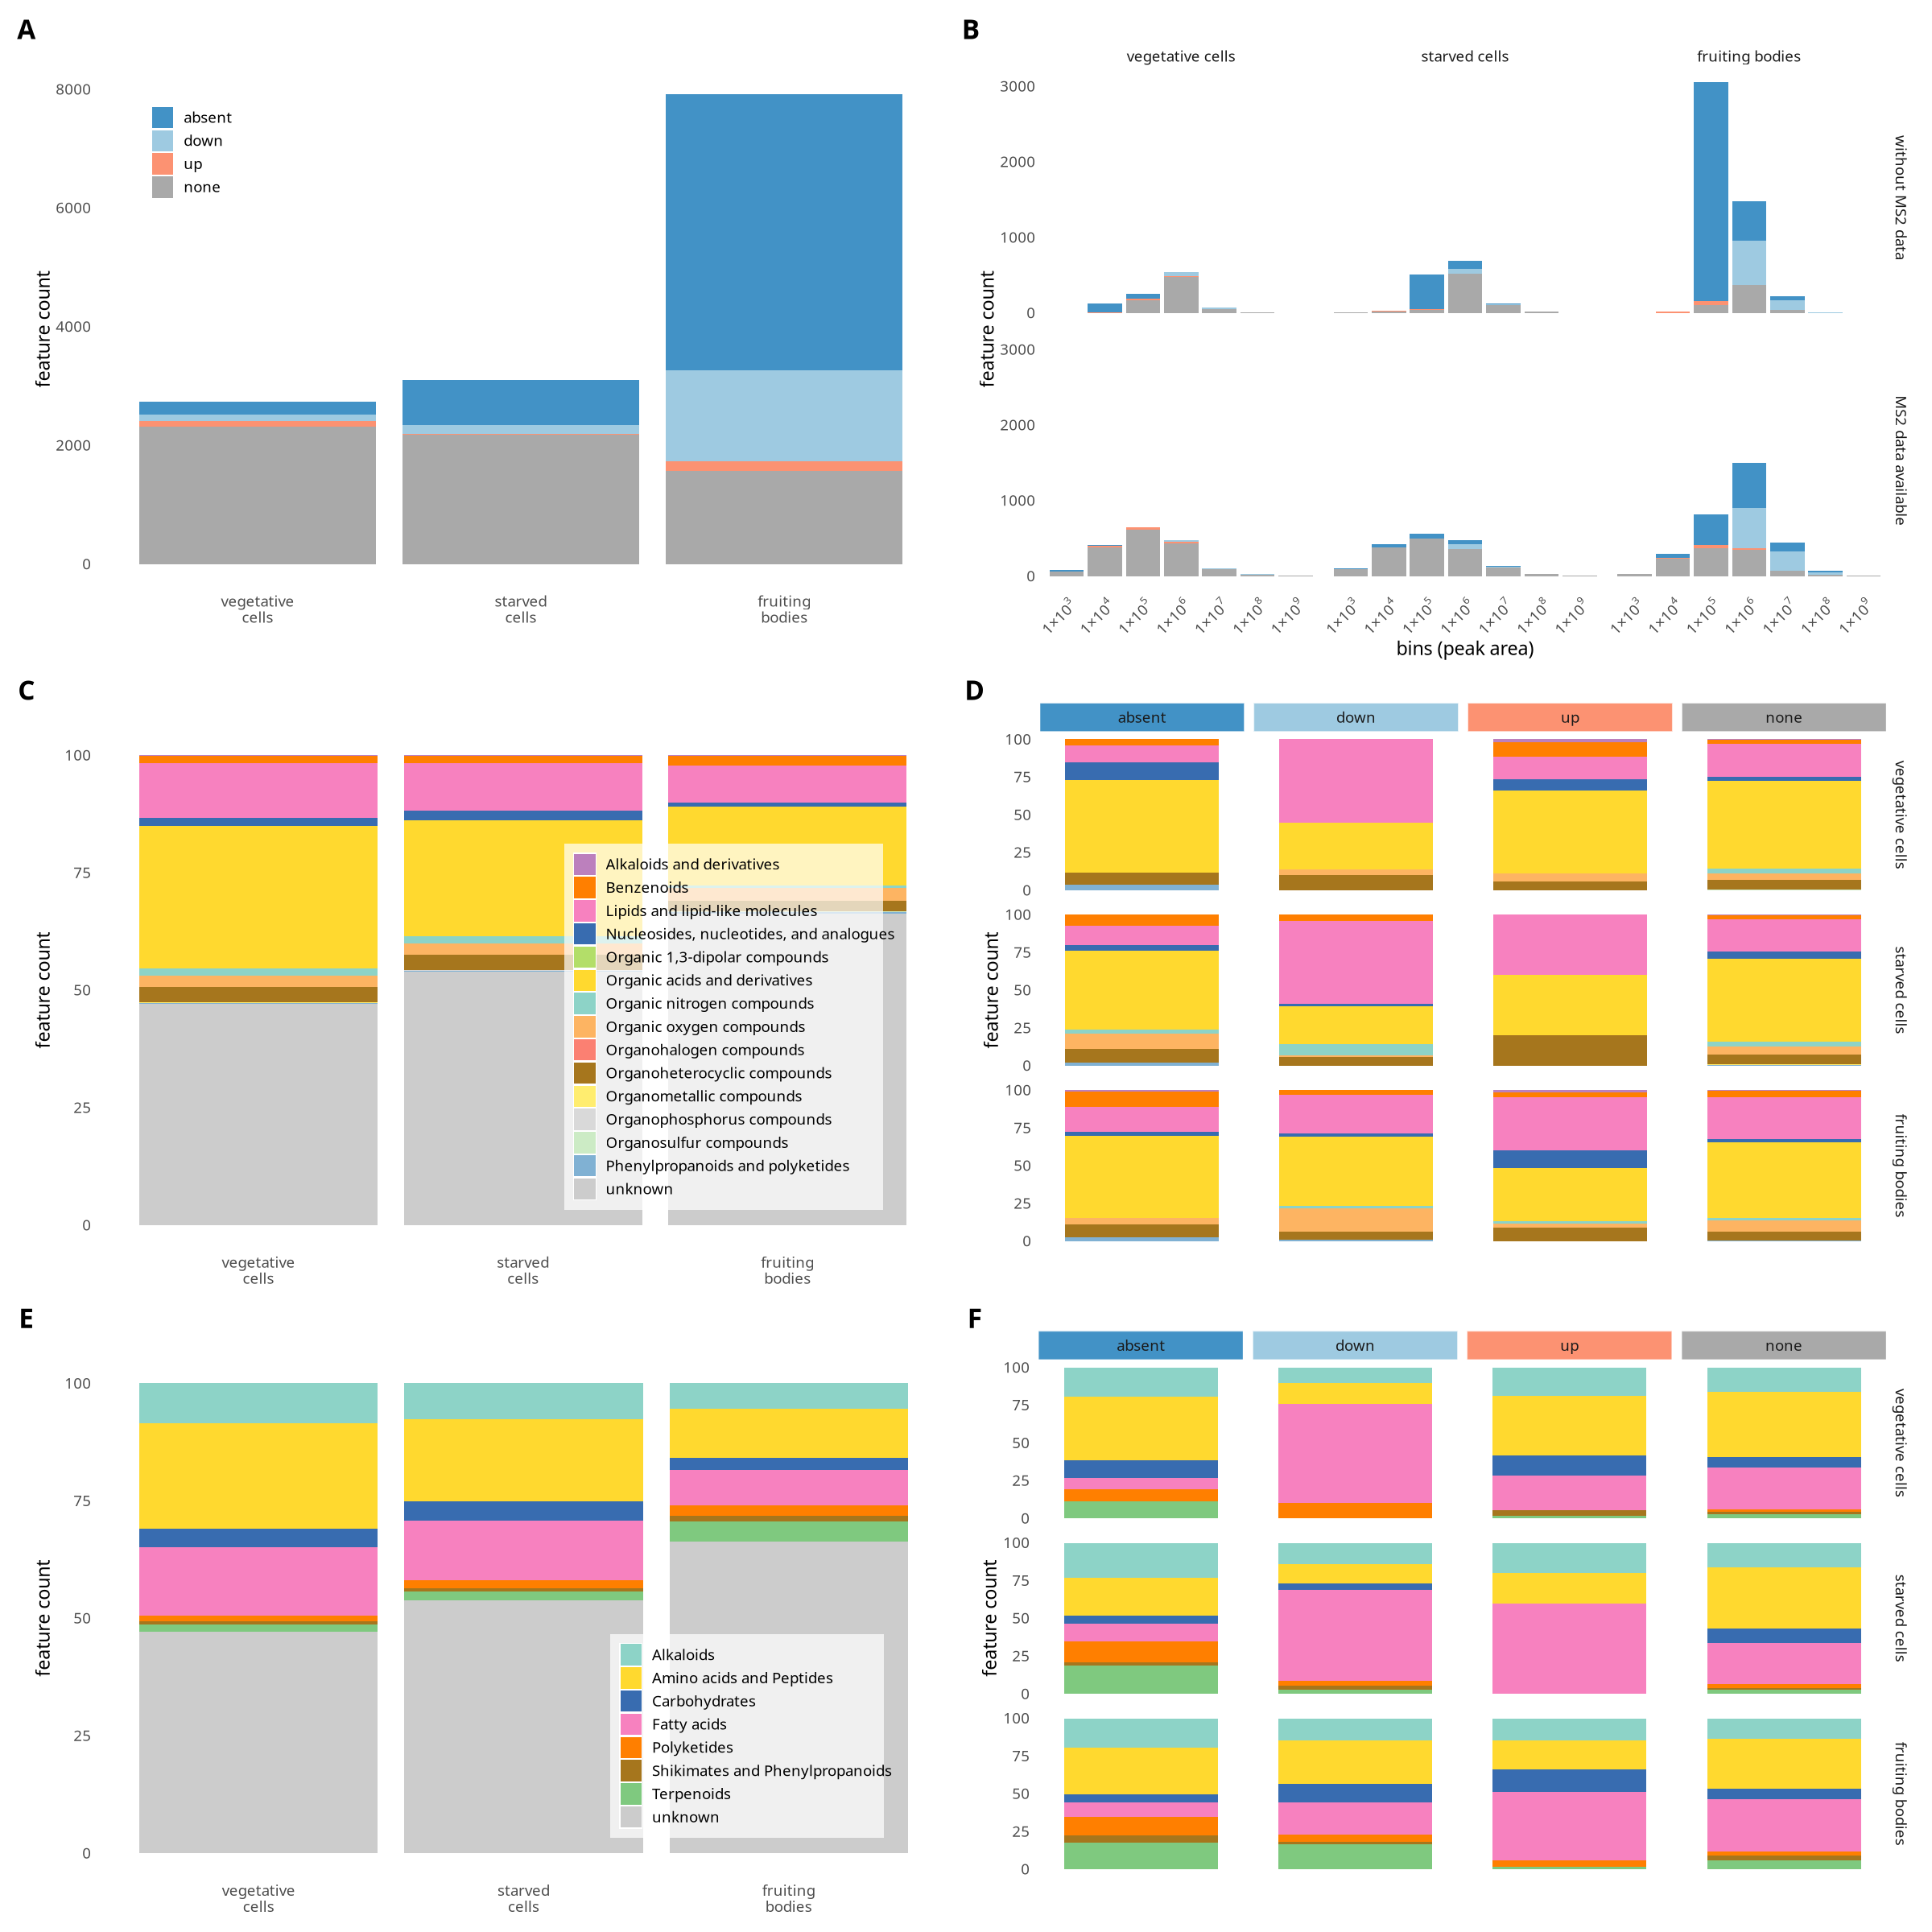

In [21]:
options(repr.plot.width=20, repr.plot.height=20) 
(changeCount_overview_plot | changeCount_overview_msms_bins) / 
(CFsuperclassCount_overview_plot + CFsuperclassCount_overview_plot_changes) / 
(NPCpathwayCount_overview_plot + NPCpathwayCount_overview_plot_changes) + 
  plot_annotation(tag_levels = 'A') & theme(plot.tag = element_text(size = 20, face = "bold"))

### Second-order annotations
Generates stacked bar plots showing the distribution of ClassyFire classes and NPClassifier superclasses, grouped by pathways across developmental stages.

#### ClassyFire class overview


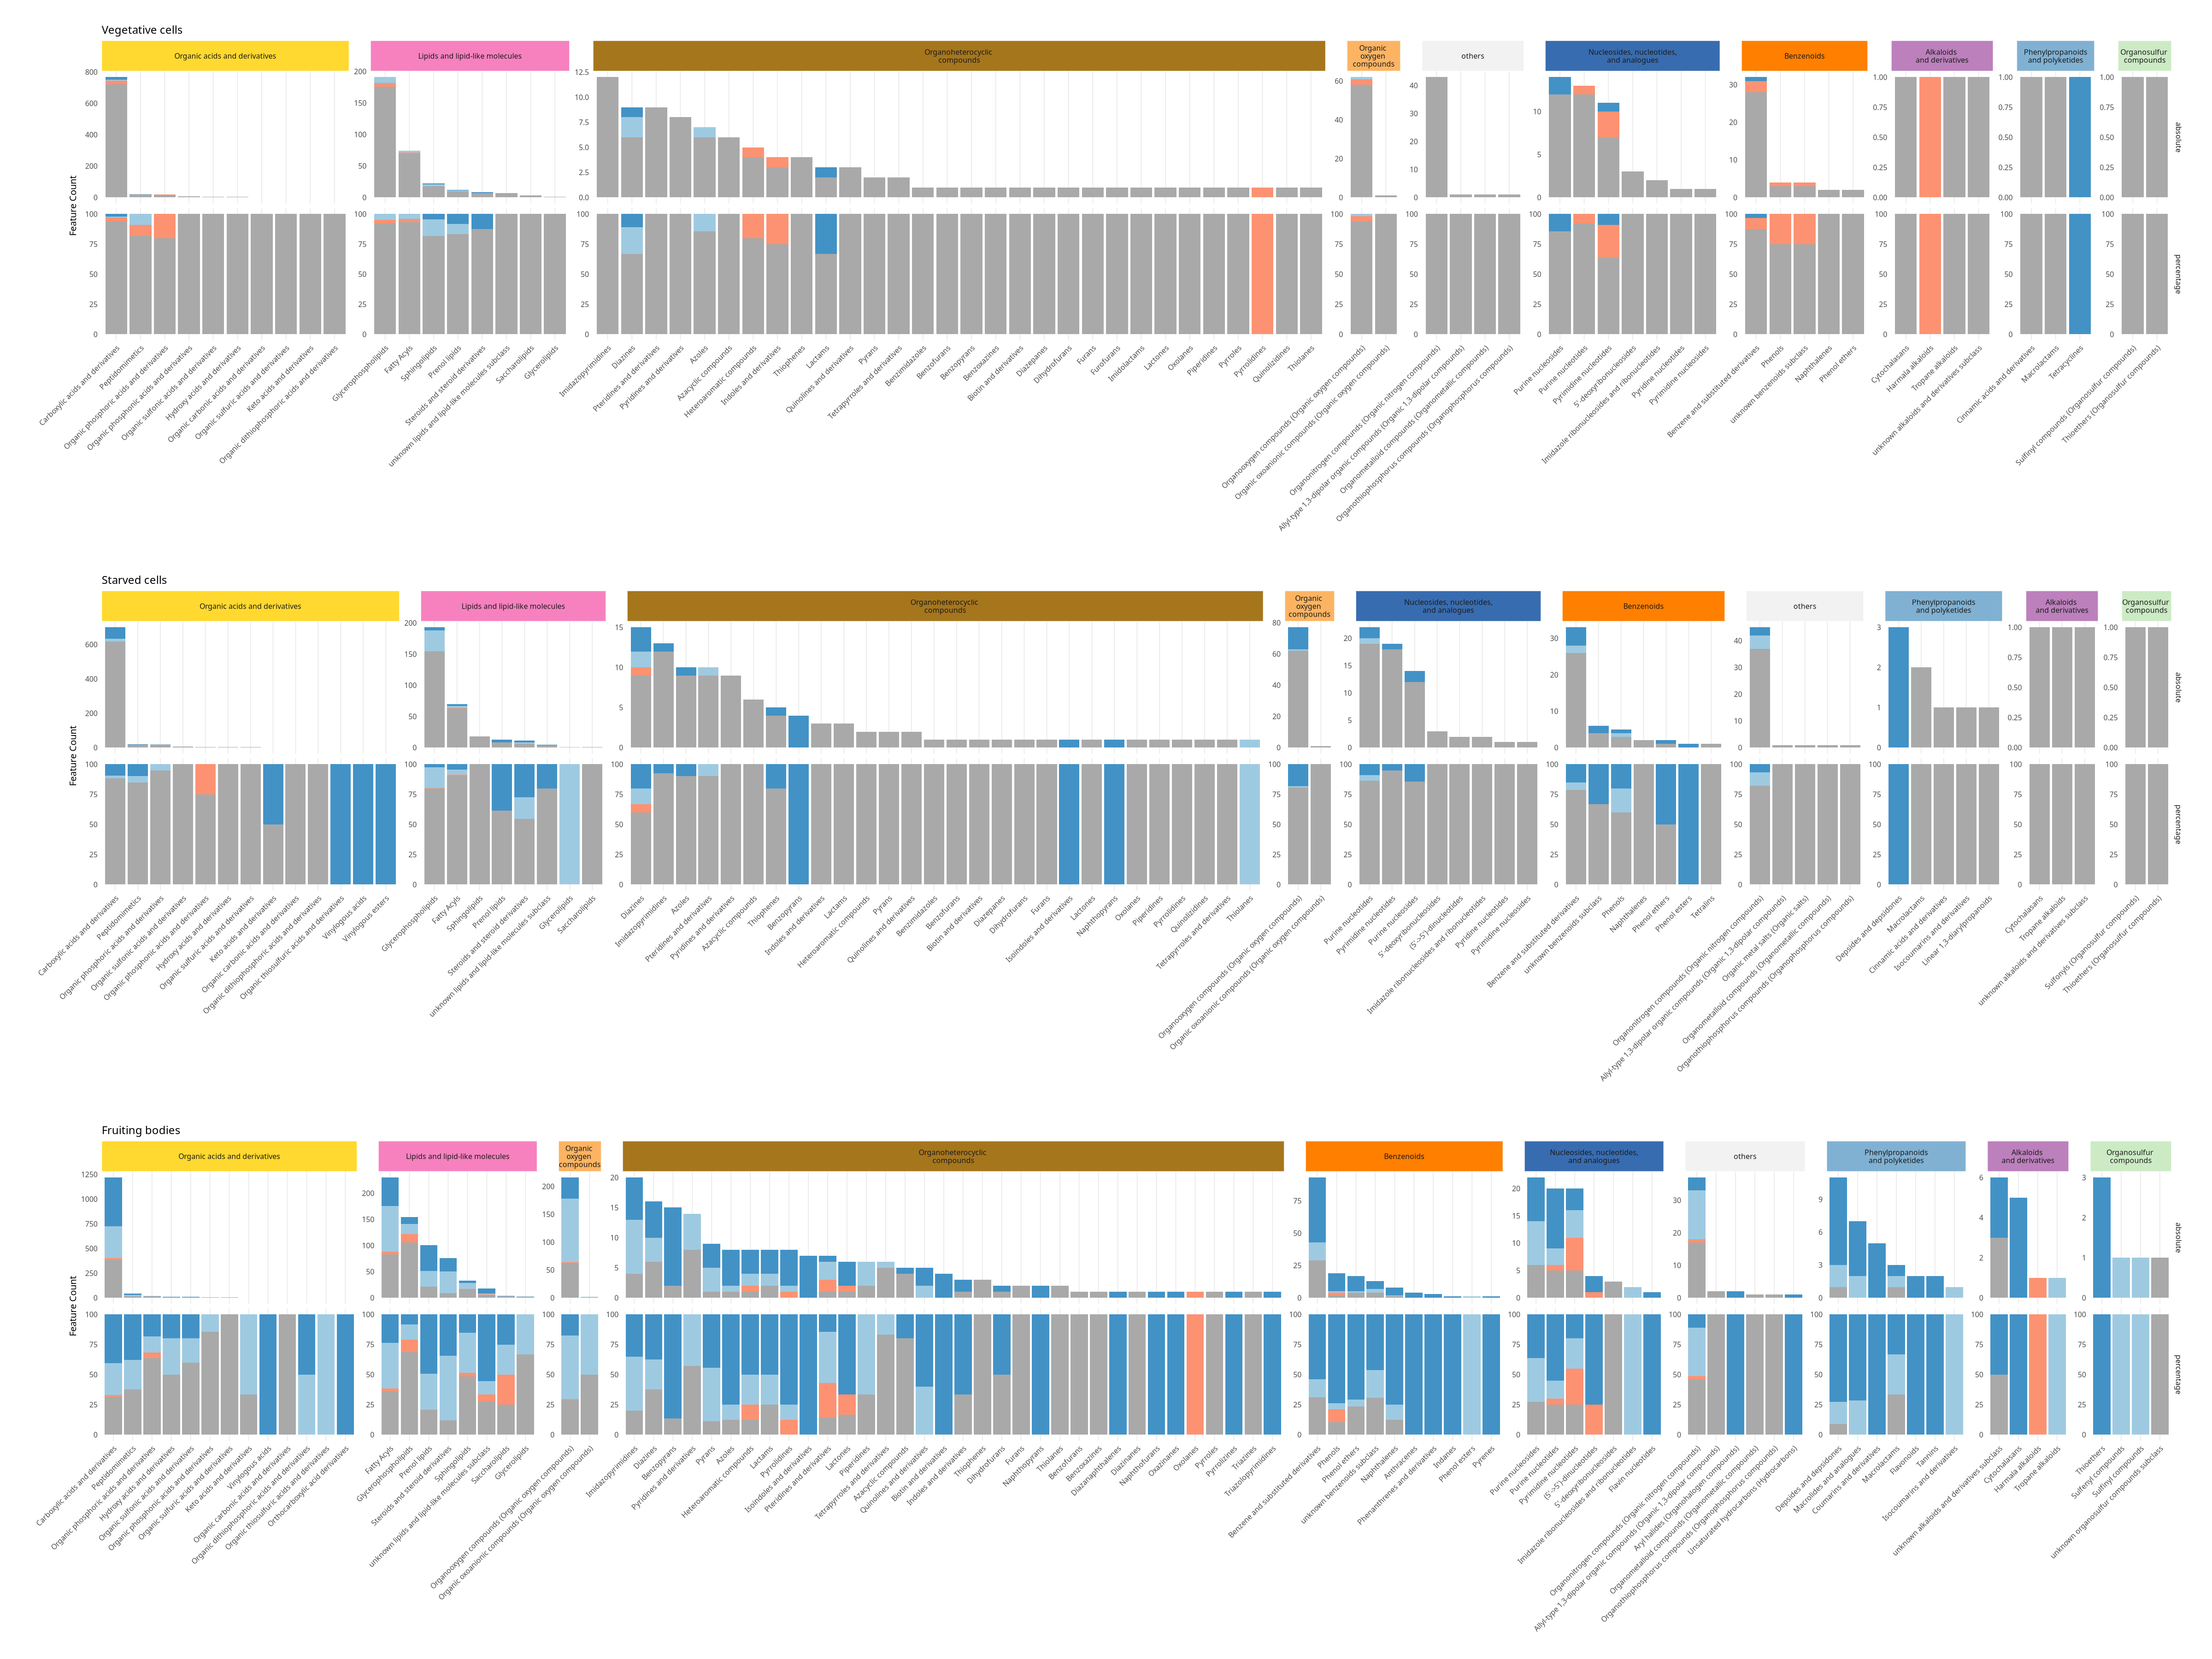

In [22]:
# Define function to create combined class/subclass plot
create_combined_plot_classyfire <- function(ft_changes, stage_selected) {
  
  # Transform unknown subclass names
  ft_changes <- ft_changes %>%
    mutate(
      sirius_ClassyFire.class = ifelse(
        sirius_ClassyFire.class == "unknown",
        paste0("unknown ", str_to_lower(sirius_ClassyFire.superclass), " subclass"),
        sirius_ClassyFire.class
      )
    )
  
  # Calculate total counts per subclass
  total_subclass_counts <- ft_changes %>%
    filter(sirius_ClassyFire.superclass != "unknown", stage == stage_selected) %>%
    group_by(sirius_ClassyFire.superclass, sirius_ClassyFire.class) %>%
    summarise(total_count = n(), .groups = 'drop')
  
  # Count features per change/superclass/subclass
  ft_count <- ft_changes %>%
    filter(sirius_ClassyFire.superclass != "unknown", stage == stage_selected) %>%
    group_by(stage, change, sirius_ClassyFire.superclass, sirius_ClassyFire.class) %>%
    summarise(count = n(), .groups = 'drop') %>%
    left_join(total_subclass_counts, by = c("sirius_ClassyFire.superclass", "sirius_ClassyFire.class"))
  
  # Count number of subclasses per superclass
  superclass_subclass_count <- ft_changes %>%
    filter(sirius_ClassyFire.superclass != "unknown", stage == stage_selected) %>%
    group_by(sirius_ClassyFire.superclass) %>%
    summarise(num_subclasses = n_distinct(sirius_ClassyFire.class), .groups = 'drop')
  
  # Add number of subclasses
  ft_count <- ft_count %>%
    left_join(superclass_subclass_count, by = "sirius_ClassyFire.superclass")
  
  # Prepare plotting data
  filtered_ft_count <- ft_count %>%
    group_by(sirius_ClassyFire.superclass) %>%
    mutate(num_subclasses = n_distinct(sirius_ClassyFire.class)) %>%
    ungroup() %>%
    mutate(
      superclass_plot = ifelse(num_subclasses <= 1, "others", sirius_ClassyFire.superclass),
      subclass_plot = ifelse(
        num_subclasses <= 2 & !grepl("unknown", sirius_ClassyFire.class),
        paste0(sirius_ClassyFire.class, " (", sirius_ClassyFire.superclass, ")"),
        sirius_ClassyFire.class
      )
    )
  
  # Define factor order
  superclass_order <- filtered_ft_count %>%
    group_by(superclass_plot) %>%
    summarise(total_count = sum(count), .groups = "drop") %>%
    arrange(desc(total_count)) %>%
    pull(superclass_plot) %>%
    unique() %>%
    c("others") %>%
    unique()
  
  subclass_order <- filtered_ft_count %>%
    group_by(superclass_plot, subclass_plot) %>%
    summarise(total_count = sum(count), .groups = "drop") %>%
    arrange(desc(total_count)) %>%
    pull(subclass_plot)
  
  filtered_ft_count <- filtered_ft_count %>%
    mutate(
      superclass_plot = factor(superclass_plot, levels = superclass_order),
      subclass_plot = factor(subclass_plot, levels = subclass_order)
    )
  
  # Add absolute and percentage counts
  ft_count_total <- filtered_ft_count %>% mutate(count_type = "absolute")
  ft_count_percentage <- filtered_ft_count %>%
    mutate(count = (count / total_count) * 100, count_type = "percentage")
  
  combined_ft_count <- bind_rows(ft_count_total, ft_count_percentage) %>%
    mutate(
      superclass_plot = factor(superclass_plot, levels = superclass_order),
      subclass_plot = factor(subclass_plot, levels = subclass_order)
    )
  
  # Label dictionary for facet titles
  rename_dict <- c(
    "Organic nitrogen compounds" = "Organic \nnitrogen \ncompounds",
    "Organic acids and derivatives" = "Organic acids and derivatives",
    "Nucleosides, nucleotides, and analogues" = "Nucleosides, nucleotides,\nand analogues",
    "Lipids and lipid-like molecules" = "Lipids and lipid-like molecules",
    "unknown" = "unknown",
    "Benzenoids" = "Benzenoids",
    "Organoheterocyclic compounds" = "Organoheterocyclic \ncompounds",
    "Organic 1,3-dipolar compounds" = "Organic \n1,3-dipolar \ncompounds",
    "Phenylpropanoids and polyketides" = "Phenylpropanoids\nand polyketides",
    "Organic oxygen compounds" = "Organic \noxygen \ncompounds",
    "Alkaloids and derivatives" = "Alkaloids \nand derivatives",
    "Organosulfur compounds" = "Organosulfur \ncompounds",
    "Organometallic compounds" = "Organometallic \ncompounds",
    "Organophosphorus compounds" = "Organophosphorus \ncompounds",
    "Organohalogen compounds" = "Organohalogen \ncompounds",
    "others" = "others",
    "absolute" = "absolute",
    "percentage" = "percentage"
  )
  
  labeller <- as_labeller(rename_dict)
  
  unique_superclasses <- levels(combined_ft_count$superclass_plot)
  facet_fill <- sapply(unique_superclasses, function(sc) {
    if (sc %in% names(ClassyFire.superclass.colors)) {
      ClassyFire.superclass.colors[[sc]]
    } else {
      "grey95"
    }
  })
  facet_colors <- rep("white", length(unique_superclasses))
  
  strip <- strip_themed(
    background_x = elem_list_rect(
      fill = unname(facet_fill),
      color = facet_colors
    )
  )
  
  # Create the plot
  combined_plot <- combined_ft_count %>%
    mutate(change = factor(change, levels = c("abs", "down", "up", "none"))) %>%
    ggplot(aes(fill = change, y = count, x = subclass_plot)) +
    geom_bar(position = "stack", stat = "identity") +
    xlab(NULL) +
    ylab("Feature Count") +
    labs(fill = NULL) +
    scale_fill_manual(values = change_colors) +
    theme_minimal(base_size = 12) +
    facet_grid2(
      count_type ~ superclass_plot,
      scales = "free",
      space = "free",
      independent = "y",
      drop = TRUE,
      labeller = labeller,
      strip = strip
    ) +
    theme(
      legend.position = "none",
      panel.grid.minor.y = element_blank(),
      panel.grid.major.y = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      plot.margin = unit(c(1, 1, 1, 3), "cm")
    )
  
  return(combined_plot)
}

# Create and combine stage-specific plots
subclass_plot_veg <- create_combined_plot_classyfire(ft_changes, "veg") + ggtitle("Vegetative cells")
subclass_plot_stv <- create_combined_plot_classyfire(ft_changes, "stv") + ggtitle("Starved cells")
subclass_plot_fbs <- create_combined_plot_classyfire(ft_changes, "fbs") + ggtitle("Fruiting bodies")

options(repr.plot.width = 40, repr.plot.height = 30)
combined_plots <- subclass_plot_veg / subclass_plot_stv / subclass_plot_fbs
combined_plots


#### NPC superclass and pathway overview


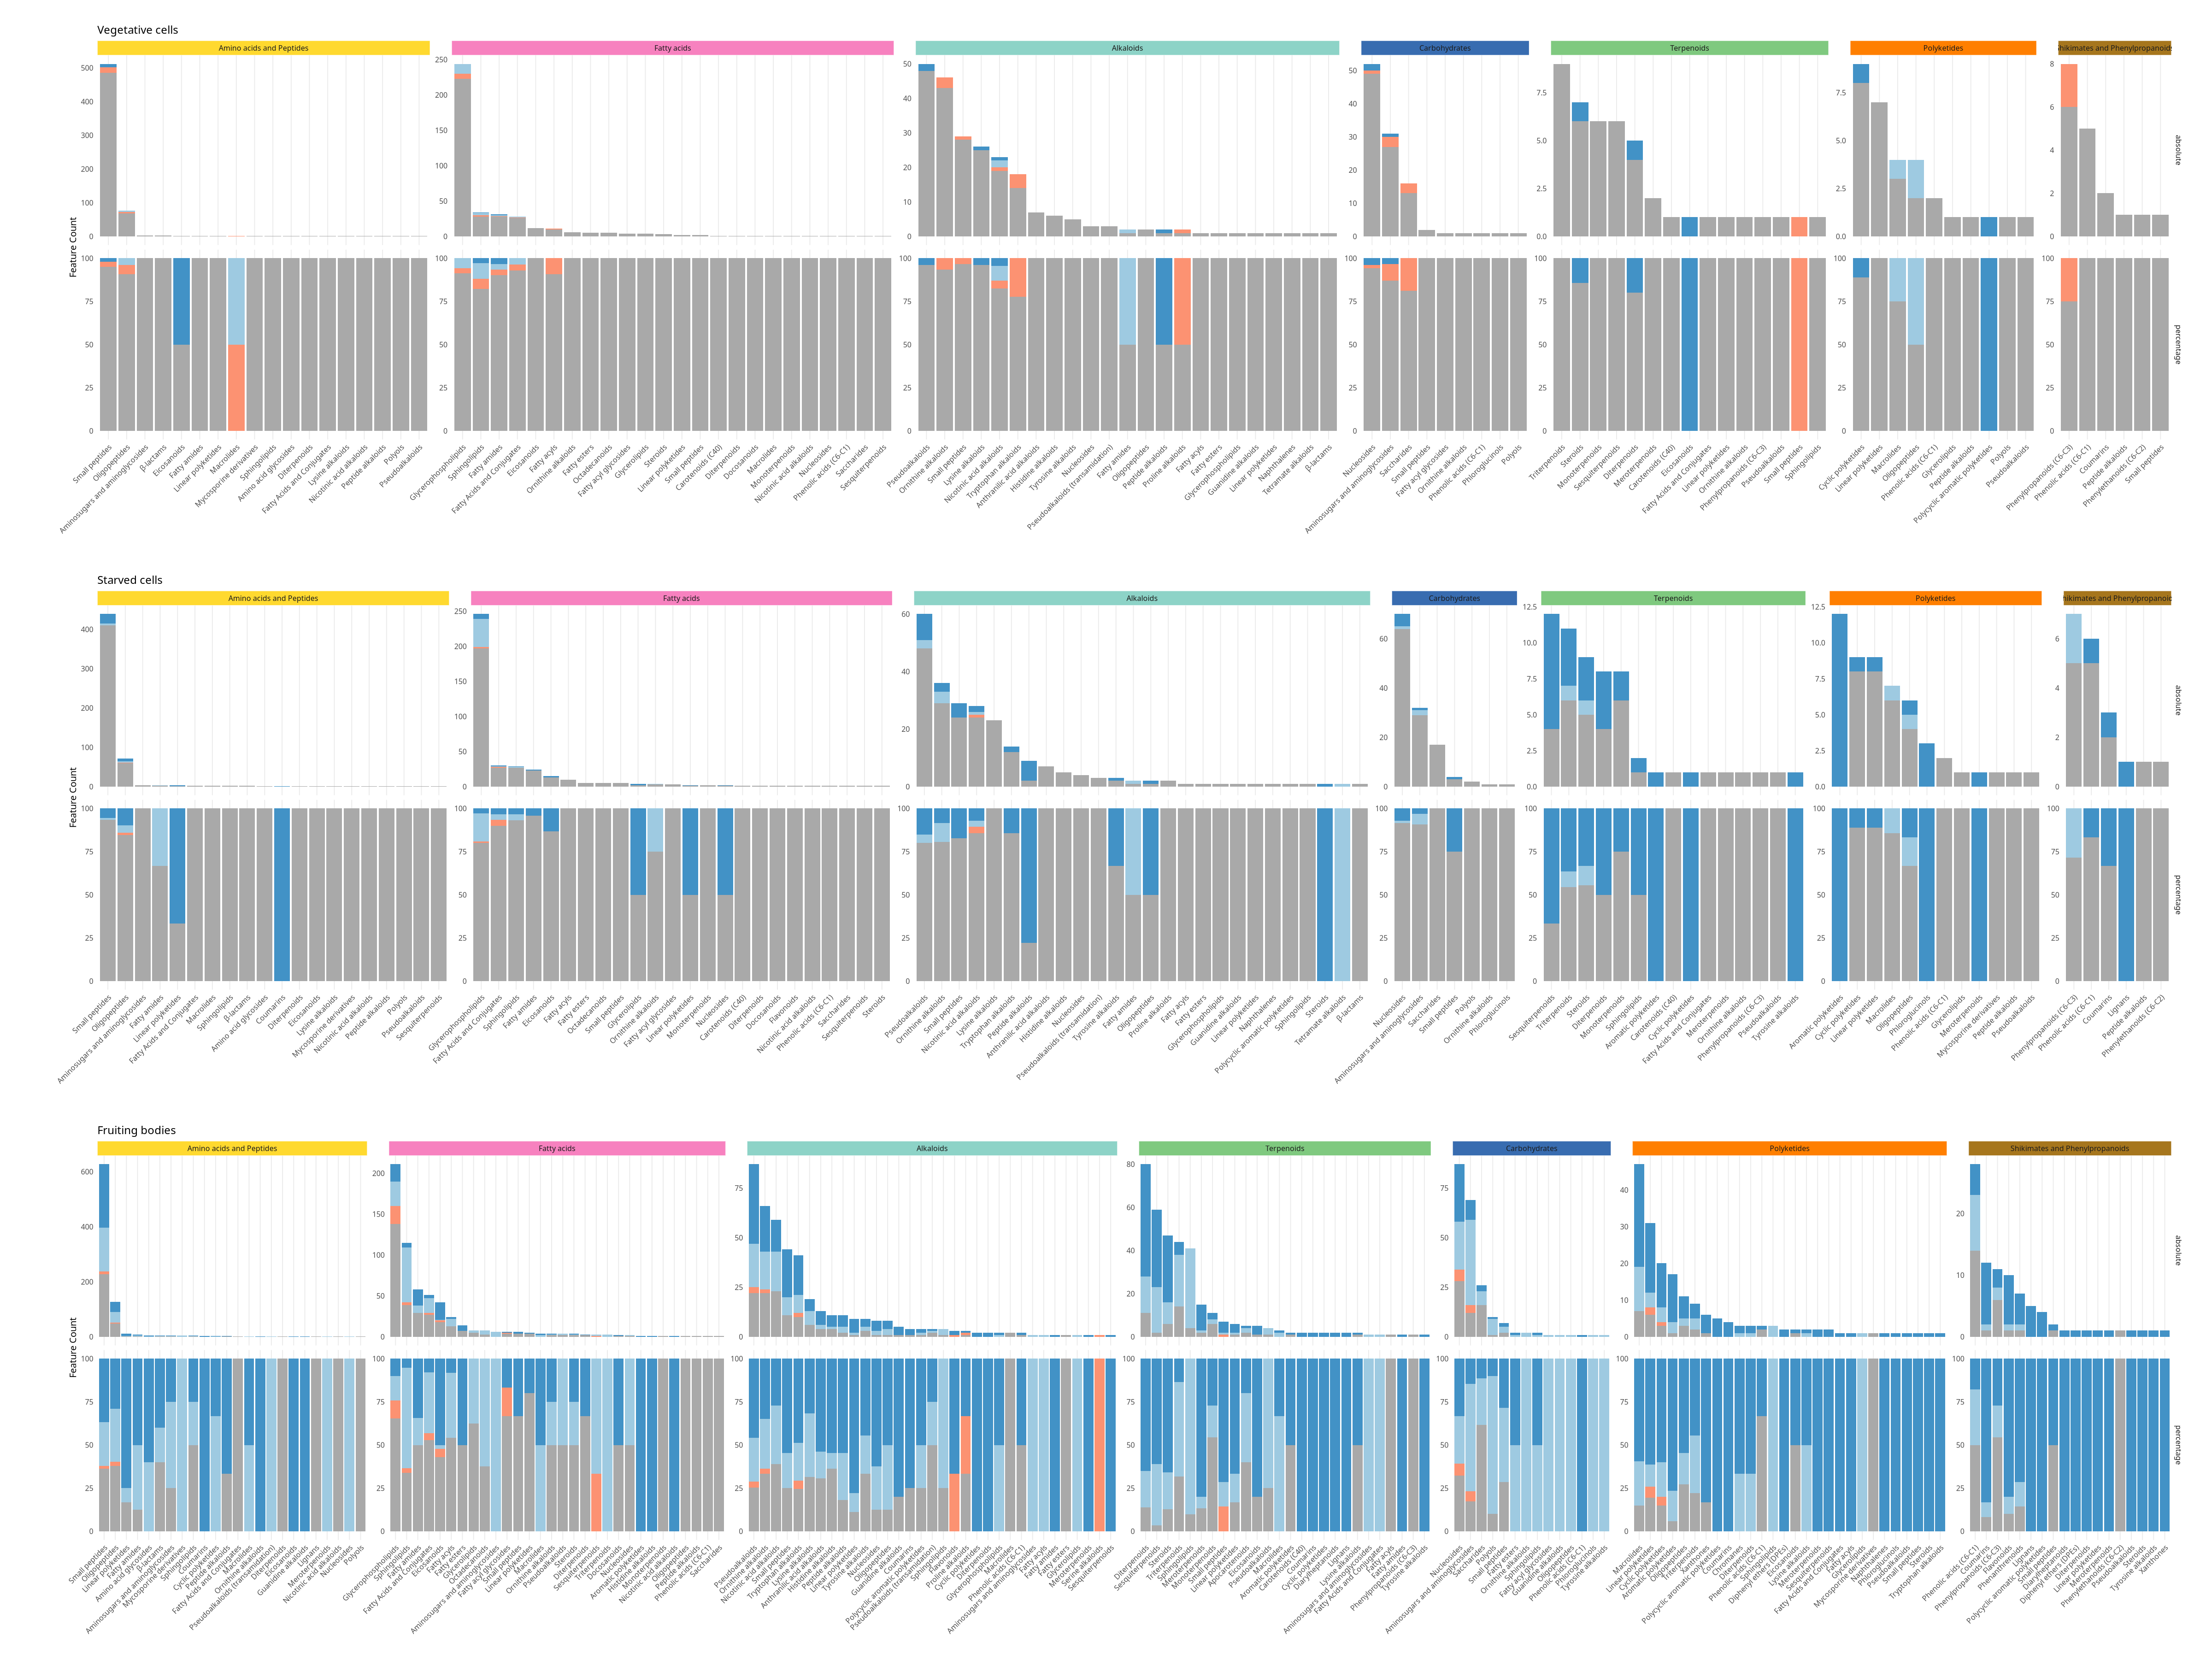

In [23]:
# Define function to create combined pathway/class plot
create_combined_plot_npc <- function(ft_changes, stage_selected) {
  
  # Calculate total counts per class
  total_class_counts <- ft_changes %>%
    filter(sirius_NPC.pathway != "unknown", stage == stage_selected) %>%
    group_by(sirius_NPC.pathway, sirius_NPC.superclass) %>%
    summarise(total_count = n(), .groups = 'drop')
  
  # Count features per change/pathway/class
  ft_count <- ft_changes %>%
    mutate(
      sirius_NPC.superclass = ifelse(
        sirius_NPC.superclass == "unknown",
        paste0("unknown ", str_to_lower(sirius_NPC.pathway), " class"),
        sirius_NPC.superclass
      )
    ) %>%
    filter(sirius_NPC.pathway != "unknown", stage == stage_selected) %>%
    group_by(stage, change, sirius_NPC.pathway, sirius_NPC.superclass) %>%
    summarise(count = n(), .groups = 'drop') %>%
    left_join(total_class_counts, by = c("sirius_NPC.pathway", "sirius_NPC.superclass"))
  
  # Count number of classes per pathway
  pathway_class_count <- ft_changes %>%
    filter(sirius_NPC.pathway != "unknown", stage == stage_selected) %>%
    group_by(sirius_NPC.pathway) %>%
    summarise(num_classes = n_distinct(sirius_NPC.superclass), .groups = 'drop')
  
  # Add number of classes to ft_count
  ft_count <- ft_count %>%
    left_join(pathway_class_count, by = "sirius_NPC.pathway")
  
  # Prepare data for plotting
  filtered_ft_count <- ft_count %>%
    group_by(sirius_NPC.pathway) %>%
    mutate(num_classes = n_distinct(sirius_NPC.superclass)) %>%
    ungroup() %>%
    mutate(
      pathway_plot = ifelse(num_classes <= 2, "others", sirius_NPC.pathway),
      class_order_key = paste0(pathway_plot, "_", sirius_NPC.superclass)
    )
  
  # Define factor levels
  class_order <- filtered_ft_count %>%
    group_by(pathway_plot, sirius_NPC.superclass, class_order_key) %>%
    summarise(total_count = sum(count), .groups = "drop") %>%
    arrange(desc(total_count)) %>%
    pull(class_order_key) %>%
    unique()
  
  pathway_order <- filtered_ft_count %>%
    group_by(pathway_plot) %>%
    summarise(total_count = sum(count), .groups = "drop") %>%
    arrange(desc(total_count)) %>%
    pull(pathway_plot) %>%
    unique() %>%
    c("others") %>%
    unique()
  
  filtered_ft_count <- filtered_ft_count %>%
    mutate(
      pathway_plot = factor(pathway_plot, levels = pathway_order),
      class_factor = factor(class_order_key, levels = class_order)
    )
  
  # Add absolute and percentage counts
  ft_count_total <- filtered_ft_count %>% mutate(count_type = "absolute")
  ft_count_percentage <- filtered_ft_count %>%
    mutate(count = (count / total_count) * 100, count_type = "percentage")
  
  combined_ft_count <- bind_rows(ft_count_total, ft_count_percentage)
  
  # Label dictionary for facet titles
  rename_dict <- c(
    "Alkaloids" = "Alkaloids",
    "Amino acids and Peptides" = "Amino acids and Peptides",
    "Carbohydrates" = "Carbohydrates",
    "Fatty acids" = "Fatty acids",
    "unknown" = "unknown",
    "Polyketides" = "Polyketides",
    "Shikimates and Phenylpropanoids" = "Shikimates and Phenylpropanoids",
    "Terpenoids" = "Terpenoids",
    "others" = "others",
    "absolute" = "absolute",
    "percentage" = "percentage"
  )
  
  labeller <- as_labeller(rename_dict)
  
  unique_pathways <- levels(filtered_ft_count$pathway_plot)
  facet_fill <- sapply(unique_pathways, function(pw) {
    if (pw %in% names(NPC.pathway.colors)) {
      NPC.pathway.colors[[pw]]
    } else {
      "grey95"
    }
  })
  facet_colors <- rep("white", length(unique_pathways))
  
  strip <- strip_themed(
    background_x = elem_list_rect(
      fill = unname(facet_fill),
      color = facet_colors
    )
  )
  
  # Create the plot
  combined_plot <- combined_ft_count %>%
    mutate(change = factor(change, levels = c("abs", "down", "up", "none"))) %>%
    ggplot(aes(fill = change, y = count, x = class_factor)) +
    geom_bar(position = "stack", stat = "identity") +
    xlab(NULL) +
    ylab("Feature Count") +
    labs(fill = NULL) +
    scale_fill_manual(values = change_colors) +
    scale_x_discrete(labels = function(x) gsub(".*_", "", x)) +
    theme_minimal(base_size = 12) +
    facet_grid2(
      count_type ~ pathway_plot,
      scales = "free",
      space = "free",
      independent = "y",
      drop = TRUE,
      labeller = labeller,
      strip = strip
    ) +
    theme(
      legend.position = "none",
      panel.grid.minor.y = element_blank(),
      panel.grid.major.y = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      plot.margin = unit(c(1, 1, 1, 3), "cm")
    )
  
  return(combined_plot)
}

# Create and combine stage-specific plots
subclass_plot_veg <- create_combined_plot_npc(ft_changes, "veg") + ggtitle("Vegetative cells")
subclass_plot_stv <- create_combined_plot_npc(ft_changes, "stv") + ggtitle("Starved cells")
subclass_plot_fbs <- create_combined_plot_npc(ft_changes, "fbs") + ggtitle("Fruiting bodies")

options(repr.plot.width = 40, repr.plot.height = 30)
combined_plots <- subclass_plot_veg / subclass_plot_stv / subclass_plot_fbs
combined_plots


## Export feature table for supplementary information

Setup paths and create export directory

In [55]:
# Output path
output_dir <- file.path(wd, "04_results", "tables")
output_file <- file.path(output_dir, "Supplementary File 2 – Metabolomics_results.xlsx")

# Create directory if needed
if (!dir.exists(output_dir)) dir.create(output_dir, recursive = TRUE)

 Prepare export tables

In [51]:
# Define columns for feature overview
overview_cols <- c(
  "feature", "mode", "mz", 
  "rt", "rt_range.min", "rt_range.max",
  "change_veg", "change_stv", "change_fbs", 
  "veg_log2FC", "veg_pvalue", "veg_wt_mean", "veg_ko_mean", "veg_wt_npeaks", "veg_ko_npeaks",
  "stv_log2FC", "stv_pvalue", "stv_wt_mean", "stv_ko_mean", "stv_wt_npeaks", "stv_ko_npeaks",
  "fbs_log2FC", "fbs_pvalue", "fbs_wt_mean", "fbs_ko_mean", "fbs_wt_npeaks", "fbs_ko_npeaks",
  "metaChange_pks",
  "sirius_molecularFormula", "sirius_smiles",  
  "sirius_NPC.pathway", "sirius_NPC.superclass", "sirius_NPC.class",
  "sirius_ClassyFire.superclass", "sirius_ClassyFire.class", "sirius_ClassyFire.subclass"
)

# Clean and rename
ft_feature_overview <- ft %>%
  filter(metaChange_veg_stv_fbs != "na") %>%
  select(all_of(overview_cols)) %>%
  rename_with(~ gsub("\\.", "_", .x)) %>%
  rename(absence_pks = metaChange_pks)

# Get raw intensity data
sample_cols <- grep("^S\\d{3}_", names(ft), value = TRUE)
ft_sample_data <- ft %>%
  filter(metaChange_veg_stv_fbs != "na") %>%
  select(all_of(sample_cols))


Create description table

In [53]:
description_df <- tribble(
  ~Sheet, ~Column, ~Description,

  "Feature_Overview", "feature",
  "Unique feature ID\nused to track metabolites across comparisons",

  "Feature_Overview", "mode",
  "Ionization mode\npositive or negative",

  "Feature_Overview", "mz",
  "Mass-to-charge ratio\nof the detected feature",

  "Feature_Overview", "rt",
  "Retention time\nin minutes",

  "Feature_Overview", "rt_range_min",
  "Minimum retention time\nin the detected RT window",

  "Feature_Overview", "rt_range_max",
  "Maximum retention time\nin the detected RT window",

  "Feature_Overview", "change_[stage]",
  "Differential abundance category per developmental stage\n(stage = veg, stv, fbs):\n\n• up = increased in disfp KO\n• down = decreased in disfp KO\n• none = no significant change\n• abs = absent in KO\n• na = not present or filtered at this stage",

  "Feature_Overview", "[stage]_log2FC",
  "Log2 fold-change\nbetween disfp knockout and wild-type samples",

  "Feature_Overview", "[stage]_pvalue",
  "P-value from statistical test\nfor differential abundance",

  "Feature_Overview", "[stage]_wt_mean",
  "Mean peak area\nacross wild-type samples",

  "Feature_Overview", "[stage]_ko_mean",
  "Mean peak area\nacross disfp knockout samples",

  "Feature_Overview", "[stage]_npeaks",
  "Number of replicates\nin which the feature was detected",

  "Feature_Overview", "absence_pks",
  "PKS knockouts where this feature is absent:\n\n• disfp\n• pks5\n• pks7\n• pks25\n• pks24\n• pks24andpks25\n• pks2425 (double KO)\n• pks24_pks25_pks2425\n• pks-related = present in any of the above",

  "Feature_Overview", "sirius_molecularFormula",
  "Molecular formula\npredicted by SIRIUS based on MS/MS fragmentation",

  "Feature_Overview", "sirius_smiles",
  "SMILES string\npredicted by SIRIUS",

  "Feature_Overview", "sirius_NPC_pathway",
  "Pathway classification\nbased on NPClassifier\n(e.g., Polyketides, Terpenoids, Alkaloids)",

  "Feature_Overview", "sirius_NPC_superclass",
  "Superclass classification\nfrom NPClassifier",

  "Feature_Overview", "sirius_NPC_class",
  "Class-level annotation\nfrom NPClassifier",

  "Feature_Overview", "sirius_ClassyFire_superclass",
  "Superclass from ClassyFire chemical taxonomy\n(e.g., Lipids, Benzenoids)",

  "Feature_Overview", "sirius_ClassyFire_class",
  "Class-level annotation\nfrom ClassyFire",

  "Feature_Overview", "sirius_ClassyFire_subclass",
  "Subclass-level annotation\nfrom ClassyFire",

  "Raw_Sample_Intensities", "S123...",
  "Raw peak area intensities per sample\n(e.g., S001_veg_ko_1)\nfrom LC-MS measurements"
)


Export workbook

In [56]:
# Create workbook and sheets
wb <- createWorkbook()
addWorksheet(wb, "Feature_Overview")
addWorksheet(wb, "Raw_Sample_Intensities")
addWorksheet(wb, "Description")

# Write data
writeData(wb, "Feature_Overview", ft_feature_overview)
writeData(wb, "Raw_Sample_Intensities", ft_sample_data)

# Style for wrapped text
wrap_style <- createStyle(wrapText = TRUE, valign = "top")

# Write description table with wrapped text
writeData(wb, "Description", description_df)
addStyle(wb, "Description", style = wrap_style, rows = 1:(nrow(description_df) + 1), cols = 1:3, gridExpand = TRUE)

# Auto-adjust column width
setColWidths(wb, "Description", cols = 1:3, widths = "auto")

# Optional: freeze header
freezePane(wb, "Description", firstRow = TRUE)

# Save workbook
saveWorkbook(wb, output_file, overwrite = TRUE)
message("Exported to Excel: ", output_file)


Exported to Excel: /Net/Groups/pbtdata/07_DD/06_PPT/05_analysis/02_metabolomics/04_results/tables/Supplementary File 2 – Metabolomics_results.xlsx

